# Autoencoder
### TODO
- [X] Autoencoder
- [ ] Denoising Autoencoder
- [ ] Variational Autoencoder

In [16]:
import torch, os
import torch.nn as nn
import torch.nn.functional as F

from tqdm.notebook import tqdm

from torch import sigmoid, tanh, cat
from torch.optim import RMSprop, Adam, SGD, Adagrad
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
plt.rcParams['figure.figsize'] = [20, 8]
plt.rcParams['figure.dpi'] = 100

<img src="https://upload.wikimedia.org/wikipedia/commons/3/37/Autoencoder_schema.png"  width="400" height="200">

# Define Autoencoder Module

In [17]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_layer = nn.Linear(784, 14*14)
        self.dec_layer = nn.Linear(14*14, 784)
        
    def forward(self, x):
        x = sigmoid(self.enc_layer(x))
        x = sigmoid(self.dec_layer(x))
        return x

# Prepare data (smart way)

In [47]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor
PATH = os.getcwd()
mnist_train = FashionMNIST(root=PATH, download=True, train=True, transform=ToTensor()) # [feature, label]
mnist_test = FashionMNIST(root=PATH, download=True, train=False, transform=ToTensor()) # [feature, label]
mnist.data.shape

torch.Size([60000, 784])

# Prepare data (dumb way)
This is the written-out version. See above for doing it using PyTorch's native features.
E.g. the data transformations from PIL image to Tensor (div by 255, reshaping, etc.) can be done automatically by simply supplying the transform=ToTensor() kwarg.

In [3]:
from torchvision.datasets import FashionMNIST
PATH = os.getcwd()
mnist = FashionMNIST(root=PATH, download=True)
mnist.data = mnist.data.div(255)
mnist.data = mnist.data.reshape((60000, 784))

# Train model

  0%|          | 0/30 [00:00<?, ?it/s]

Final loss: 1288.5841064453125


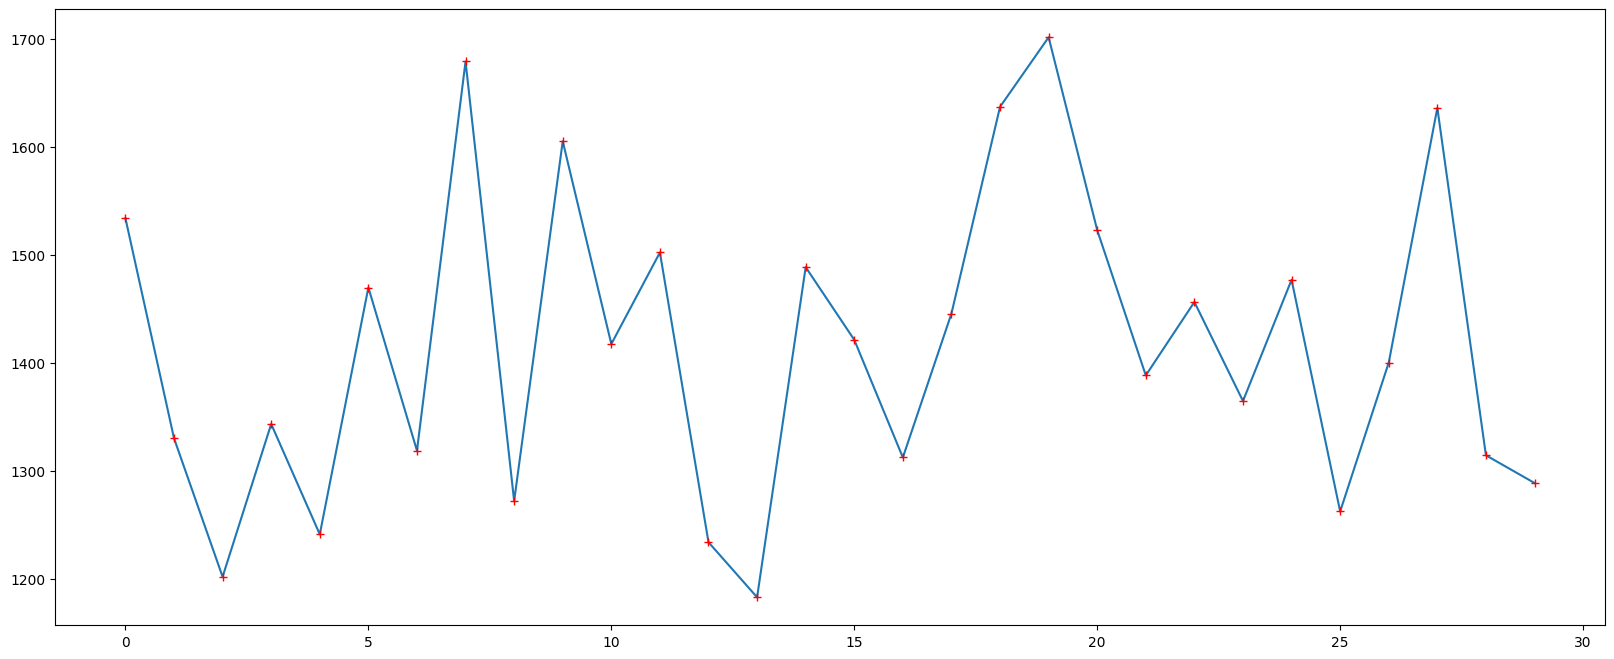

In [12]:
AE = Autoencoder()

optim = Adam(AE.parameters())
loss_fn = nn.CrossEntropyLoss(reduction='mean')
losses = []
EPOCHS = 30

for epoch in tqdm(range(EPOCHS)):
    data = mnist.data
    data = data[torch.randperm(data.size()[0])]
    mini_batches = data.reshape((2000, 30, 784))
    for batch_idx in range(mini_batches.shape[0]):
        optim.zero_grad()
        
        x = mini_batches[batch_idx]
        pred = AE(x)
        loss = loss_fn(pred, x)
        loss.backward()
        optim.step()
    losses.append(loss.item())
    #print("\r\r\r", f"Epoch: {epoch}\nLoss:{losses[-1]}", end="")

print(f"Final loss: {loss.item()}")
plt.plot(losses, '-+', mec='r')
plt.show()

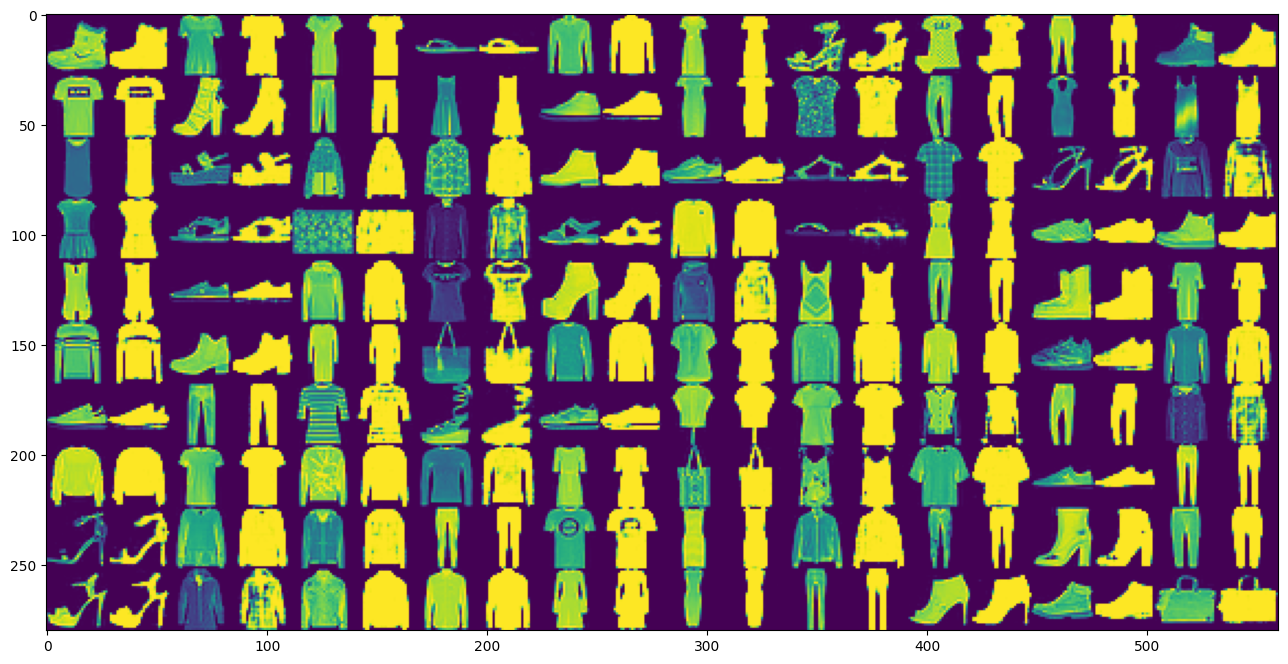

In [13]:
def construct_concatenated_image(real, model):
    final_img = cat((real[0], model(real[0].flatten()).reshape((28, 28))), 1)
    for i, re in enumerate(real[1:]):
        s = cat((re, model(real[i+1].flatten()).reshape((28, 28))), 1)
        final_img = cat((final_img, s), 0)
    return final_img

img = construct_concatenated_image(mnist.data.reshape((60000, 28, 28))[:10], AE)
for i in range(2, 11):
    new_col = construct_concatenated_image(mnist.data.reshape((60000, 28, 28))[(i-1)*10:i*10], AE)
    img = cat((img, new_col), 1)

imshow(img.detach().numpy())
plt.show()

In [51]:
AE(mnist.data.reshape((60000, 28, 28))[:10][0].flatten())

tensor([6.2255e-12, 5.1049e-12, 4.1393e-12, 3.1711e-12, 4.0158e-12, 4.1436e-12,
        3.9811e-12, 3.0260e-12, 4.0645e-12, 1.3526e-10, 2.9159e-09, 1.5659e-08,
        2.4984e-09, 9.9993e-09, 2.2517e-08, 4.5077e-08, 5.7916e-06, 1.0526e-07,
        9.8845e-10, 6.1822e-12, 5.4767e-12, 4.4467e-12, 3.6815e-12, 4.2349e-12,
        4.5161e-12, 3.6475e-12, 4.7206e-12, 3.6701e-12, 3.5083e-12, 4.7757e-12,
        4.4520e-12, 4.7479e-12, 5.8825e-12, 5.1309e-12, 6.5184e-10, 7.5198e-09,
        2.0322e-08, 1.3272e-10, 8.1780e-10, 1.8819e-09, 2.2020e-09, 1.9370e-08,
        2.9626e-06, 2.4465e-06, 2.8226e-06, 6.2128e-05, 2.4641e-05, 4.7000e-07,
        3.1751e-07, 2.0910e-08, 6.3629e-12, 6.3442e-12, 5.3791e-12, 4.7005e-12,
        3.6324e-12, 4.7780e-12, 5.0551e-12, 3.7014e-12, 4.1232e-12, 3.0315e-12,
        4.0067e-12, 1.2712e-09, 1.0051e-08, 2.2414e-08, 1.1400e-07, 9.9708e-10,
        7.5674e-10, 1.6409e-09, 3.4985e-08, 8.8317e-08, 6.8421e-06, 1.1870e-03,
        6.3068e-05, 5.7715e-05, 3.2928e-

# Cluster visualization using t-SNE

In [14]:
from sklearn.manifold import TSNE

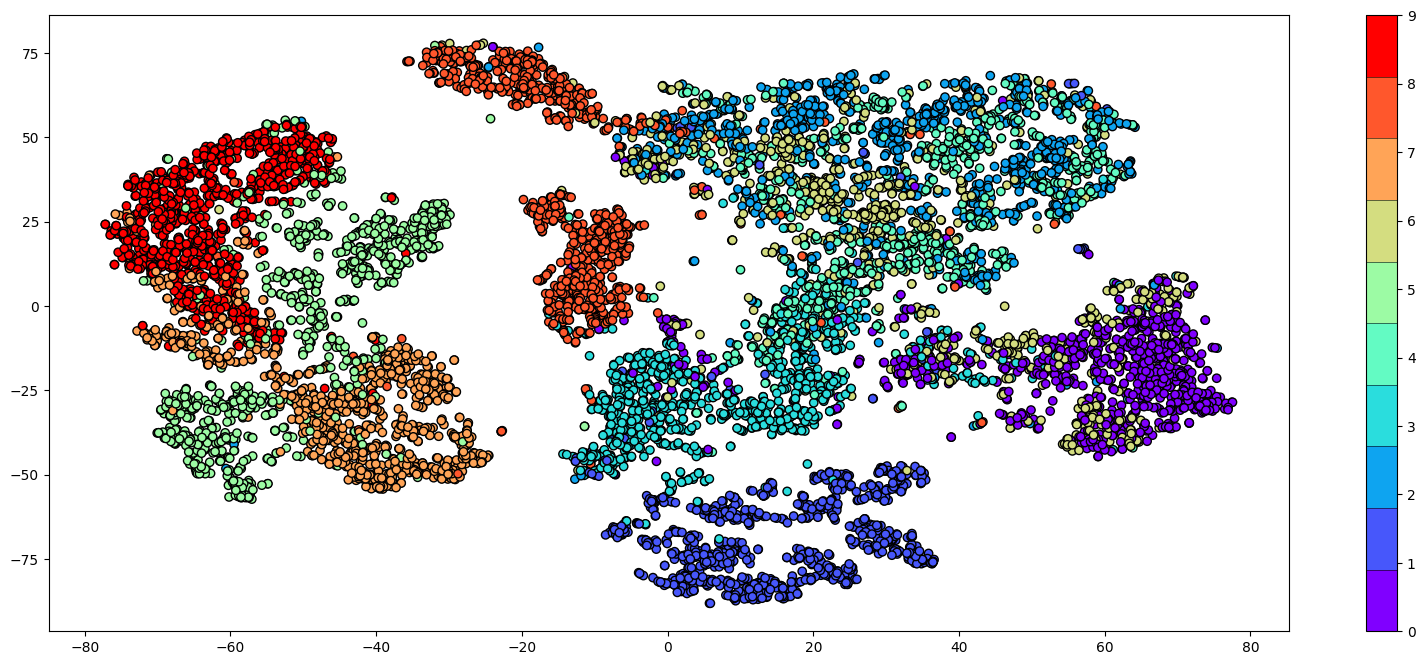

In [15]:
n_predict = 10000
x_encoded_TSNE = TSNE().fit_transform(AE(mnist.data[:n_predict]).detach().numpy())

cmap = plt.get_cmap('rainbow', 10)
plt.scatter(x_encoded_TSNE[:,0], x_encoded_TSNE[:,1], 
                c=mnist.targets[:n_predict], edgecolor='black', cmap=cmap)
plt.colorbar(drawedges=True)
plt.show()